In [1]:
# STEP 1: Import required libraries

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import math

In [2]:
# STEP 2: Load Dataset

data = fetch_california_housing()

X = data.data      # Features
y = data.target    # Target values

print("Dataset loaded successfully")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully
Features shape: (20640, 8)
Target shape: (20640,)


In [3]:
# STEP 3: Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (16512, 8)
Testing data size: (4128, 8)


In [4]:
# STEP 4: Create model

model = LinearRegression()

# STEP 5: Train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [5]:
# STEP 6: Make predictions

y_pred = model.predict(X_test)

print("First 5 predicted values:")
print(y_pred[:5])

First 5 predicted values:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [6]:
# STEP 7: Evaluate model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Evaluation Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Regression Evaluation Results:
MAE: 0.533200130495698
MSE: 0.5558915986952422
RMSE: 0.7455813830127749
R2 Score: 0.5757877060324524


In [7]:
# STEP 8: Import classification libraries

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [8]:
# STEP 9: Load Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Iris dataset loaded")
print("Feature shape:", X.shape)

Iris dataset loaded
Feature shape: (150, 4)


In [9]:
# STEP 10: Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [10]:
# STEP 11: Train classification model

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

print("Classification model trained")

Classification model trained


In [11]:
# STEP 12: Make predictions

y_pred = clf.predict(X_test)

In [12]:
# STEP 13: Evaluate classification model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print("Classification Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:")
print(cm)

Classification Results:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [13]:
# STEP 16: Import plotting library
import matplotlib.pyplot as plt

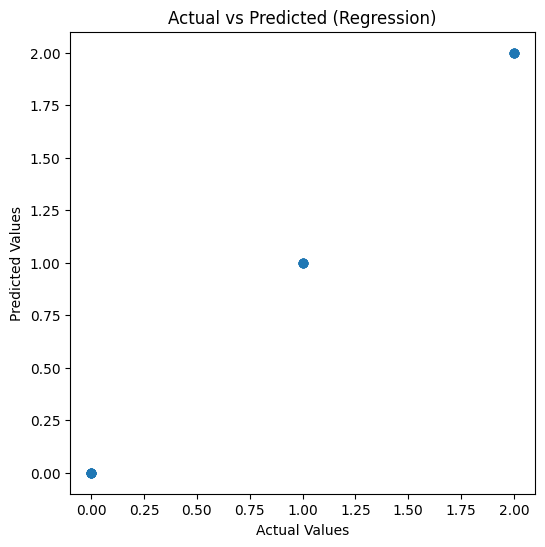

In [14]:
# STEP 17: Plot Actual vs Predicted values

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Regression)")
plt.show()

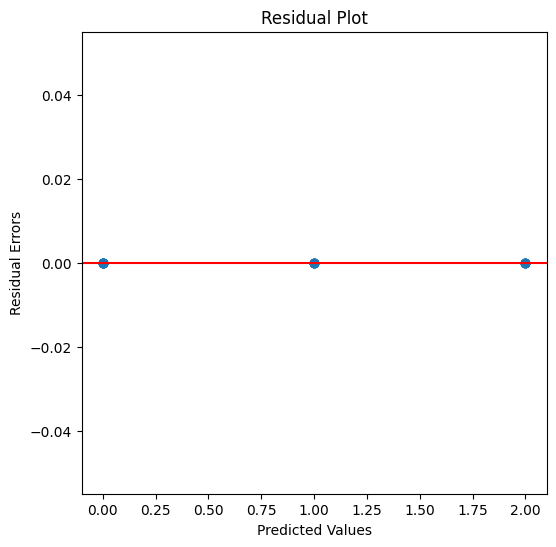

In [15]:
# STEP 18: Plot Residual Errors

residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Plot")
plt.axhline(y=0, color='r')
plt.show()

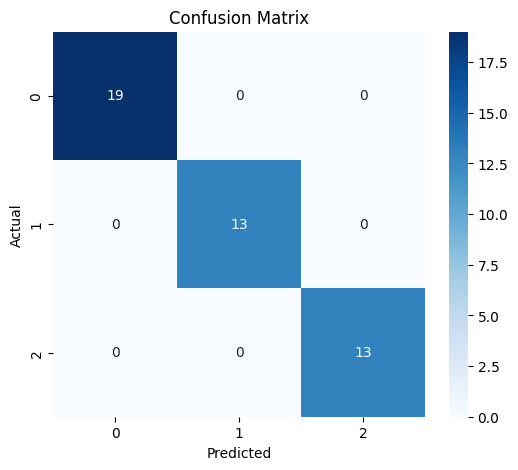

In [16]:
# STEP 19: Visual Confusion Matrix

import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.tree import DecisionTreeRegressor

In [18]:
# STEP 20: Overfitting example

overfit_model = DecisionTreeRegressor()

overfit_model.fit(X_train, y_train)

# Training prediction
train_pred = overfit_model.predict(X_train)

# Testing prediction
test_pred = overfit_model.predict(X_test)

# Calculate R2 for training and testing
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R2:", train_r2)
print("Testing R2:", test_r2)

Training R2: 1.0
Testing R2: 1.0


In [19]:
# STEP 21: Fix Overfitting by limiting depth

controlled_model = DecisionTreeRegressor(max_depth=5)

controlled_model.fit(X_train, y_train)

train_pred2 = controlled_model.predict(X_train)
test_pred2 = controlled_model.predict(X_test)

train_r2_2 = r2_score(y_train, train_pred2)
test_r2_2 = r2_score(y_test, test_pred2)

print("After Controlling Depth:")
print("Training R2:", train_r2_2)
print("Testing R2:", test_r2_2)

After Controlling Depth:
Training R2: 0.9901463963963963
Testing R2: 1.0


In [20]:
# STEP 22: Underfitting example

underfit_model = DecisionTreeRegressor(max_depth=1)

underfit_model.fit(X_train, y_train)

train_pred3 = underfit_model.predict(X_train)
test_pred3 = underfit_model.predict(X_test)

print("Underfitting Example:")
print("Training R2:", r2_score(y_train, train_pred3))
print("Testing R2:", r2_score(y_test, test_pred3))

Underfitting Example:
Training R2: 0.7265625
Testing R2: 0.7916666666666666
